# Predicting weapon use in motorcycle-related crimes in Buenos Aires City through machine learning

## Preparation

- **GitHub Repository**: [https://github.com/SSoubie/CASA0006_Assessment_gun_prediction](https://github.com/SSoubie/CASA0006_Assessment_gun_prediction)

- **Number of words**: *** (a completar al final)

- **All the package versions are the ones in the CASA computing environment**

## Table of contents

1. [Introduction](#Introduction)

2. [Research questions](#Research-questions)

3. [Data](#Data)

4. [Methodology](#Methodology)

5. [Results and discussion](#Results-and-discussion)

6. [Conclusion](#Conclusion)

7. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

A substantial body of literature has examined the spatial determinants of criminal activity (Buonanno, 2003), with a growing consensus that crime is shaped by social and economic factors, and that both offender and victim characteristics contribute to the occurrence of an offence (Dakalbab et al., 2022).

Taking the city of Buenos Aires as a case study, this work investigates whether violent crimes can be predicted from temporal, spatial and socioeconomic features using machine learning. The focus is placed on crimes committed by "*motochorros*" (motorbike-riding offenders): while overall crime in CABA has shown a declining trend since its pandemic-era peak, motorcycle-related offences have increased over the same period, making them a particularly relevant category for the design of public-safety policy [(BA DATA, 2025)](https://data.buenosaires.gob.ar/dataset/delitos).

This work combines two perspectives. On the one hand, the rational choice theory, that holds that criminal behavior is the economic choice of a rational agent (Becker, 1968): the use of a weapon, by aggravating the legal penalty associated with the offence, constitutes a deliberate decision based on a cost-benefit calculation that is shaped by environmental conditions that affect, for instance, the likelihood of evading apprehension (Buonanno, 2003). On the other hand, the Routine Activity Theory (Cohen & Felson, 1979) which conceptualizes crime as the convergence in space and time of three elements: a motivated offender, a suitable target, and the absence of a capable guardian. Under this framework, contextual features that systematically modify any of these three elements should also modify the probability of violent escalation in a predictable way.


## Research questions

[[ go back to the top ]](#Table-of-contents)

***To what extent is it possible to predict weapon use in motorcycle-related crimes in Buenos Aires City (CABA), based on temporal, spatial and socioeconomic features?***

## Data

[[ go back to the top ]](#Table-of-contents)

### Data source and preprocessing

The dataset used in this study is the result of an integration pipeline implemented in R, combining seven public sources:

| # | Source | Description | Format | Spatial unit | URL |
|---|---|---|---|---|---|
| 1 | BA Data — Crimes | Annual crime records from 2016 to 2024 | CSV | Point | [link](https://data.buenosaires.gob.ar/dataset/delitos) |
| 2 | BA Data — Police stations | Location of all police stations | GeoJSON | Point | [link](https://data.buenosaires.gob.ar/dataset/comisarias-policia-ciudad) |
| 3 | BA Data — Streets | Official street network with type classification | GeoJSON | Line | [link](https://data.buenosaires.gob.ar/dataset/calles) |
| 4 | BA Data — ATMs | Location and operator of all ATMs | CSV | Point | [link](https://data.buenosaires.gob.ar/dataset/cajeros-automaticos) |
| 5 | BA Data — Banks | Location of all bank branches | CSV | Point | [link](https://data.buenosaires.gob.ar/dataset/bancos) |
| 6 | La Nación | Real estate price per square metre (USD) by neighbourhood | CSV | Neighbourhood | [link](https://www.lanacion.com.ar/propiedades/casas-y-departamentos/mapa-interactivo-los-precios-de-venta-y-de-alquiler-de-las-propiedades-en-cada-barrio-porteno-nid22022026/) |
| 7 | BA Data — Census 2010 | Population density and households with Unsatisfied Basic Needs | Shapefile | Census tract | [link](https://data.buenosaires.gob.ar/dataset/informacion-censal-por-radio) |

The full preprocessing script can be found in the project repository. Due to the size of the data and the depth of the transformation, it was decided to keep it separate from the original script to comply with the time limit restriction of 1hs.

The pipeline performs the following operations:

**1. Crime data filtering and deduplication**. The raw crime files  are concatenated across years and filtered to retain only motorcycle-mediated crimes with valid geographic coordinates. After de-duplication and spatial filtering against the city boundary, the resulting dataset contains **64,585 unique records** spanning from 2016 to 2024.

**2. Coordinate system handling**. All geometries are reprojected from WGS84 to **POSGAR 2007 / Argentina 5 (EPSG:5347)**, the official projected CRS for CABA, ensuring accurate distance calculations in metres.

**3. Derivation of temporal features**. From the original timestamp, several temporal indicators are derived: `night` (19:00–06:00), `banking_hours` (10:00–18:00 on workdays), `weekend`, `start_of_month` (first 7 days), `end_of_month` (last 7 days), and `business_cycle` (Summer vs Rest of the year).

**4. Spatial enrichment via nearest-feature joins**. For each crime, the exact metric distance to the nearest police station, ATM, and bank is computed. From these distances, six binary proximity variables are derived (within 100m and within 200m thresholds). The street type is assigned by joining each crime to the nearest segment of the official street network.

**5. Socioeconomic enrichment**. Each crime is joined to two complementary socioeconomic layers: real estate price per square metre (USD), aggregated at the neighbourhood level, and population density and proportion of households with Unsatisfied Basic Needs (NBI), aggregated at the census tract level.

**6. Translation**. All variable names and categorical values are translated to English to facilitate interpretation.

### Data presentation

In [11]:
## SETUP
# All the libraries were retrieved from the CASA's Computer Environment. The only exception were "SHAP" and "XGBOOST" which were used in class.
!pip install -q shap xgboost
# We import the libraries that we are going to use in this project as well as any other tools.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Methodology
# Pipeline and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_selection import mutual_info_classif

# Metrics and interpretation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance
import shap

# === Visualisation settings ===
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# === Reproducibility ===
RANDOM_STATE = 44
np.random.seed(RANDOM_STATE)

In [13]:
# We upload our data
# We set the url to fetch our dataset.
URL_DATA = "https://github.com/SSoubie/CASA0006_Assessment_gun_prediction/raw/refs/heads/main/data/delito_data.csv"

# We load the dataset
crime = pd.read_csv("data/crime_data.csv")

print(f"Our dataset has {crime.shape[0]:,} rows and {crime.shape[1]} columns.")

Our dataset has 64,585 rows and 27 columns.


In [7]:
# Let's have a quick look to it
crime.head()

,year,month,business_cycle,day,day_of_week,weekend,start_of_month,end_of_month,hour,night,...,atm_network,banks_within_100m,banks_within_200m,police_stations_within_100m,police_stations_within_200m,price_per_sqm_usd,population_density,pct_households_nbi,neighbourhood,comune
0,2016,January,Holidays,27,Wednesday,no,no,yes,12.0,no,...,BANELCO,no,no,no,no,2173,7941.622046,0.057508,LINIERS,Comuna 9
1,2016,January,Holidays,18,Monday,no,no,no,12.0,no,...,BANELCO,no,no,no,no,2173,7064.506597,0.102662,LINIERS,Comuna 9
2,2016,January,Holidays,28,Thursday,no,no,yes,9.0,no,...,BANELCO,yes,yes,no,no,2173,7125.416986,0.006803,LINIERS,Comuna 9
3,2016,January,Holidays,27,Wednesday,no,no,yes,21.0,yes,...,BANELCO,yes,yes,no,no,2173,10819.971031,0.029289,LINIERS,Comuna 9
4,2016,January,Holidays,15,Friday,no,no,no,5.0,yes,...,BANELCO,yes,yes,no,no,2737,7049.669647,0.003289,VILLA DEVOTO,Comuna 11


In [76]:
# NA values.
crime.isna().sum().sort_values(ascending=False)

hour                           84
pct_households_nbi             20
population_density             20
business_cycle                  0
day                             0
weekend                         0
day_of_week                     0
start_of_month                  0
end_of_month                    0
month                           0
year                            0
banking_hours                   0
night                           0
crime_type                      0
weapon_use                      0
atms_within_200m                0
atm_bank                        0
street_type                     0
atms_within_100m                0
banks_within_100m               0
atm_network                     0
banks_within_200m               0
police_stations_within_100m     0
price_per_sqm_usd               0
police_stations_within_200m     0
neighbourhood                   0
comune                          0
dtype: int64

We begin the exploratory analysis with the distribution of the target variable, `weapon_use`.

In [14]:
crime['weapon_use'].value_counts()

weapon_use
no     49084
yes    15501
Name: count, dtype: int64

The distribution shows moderate imbalance, with approximately 76% of crimes recorded without weapon use and 24% with it.

We now examine the distribution of each variable and identify which are informative for predicting weapon use.

#### - Time Variables

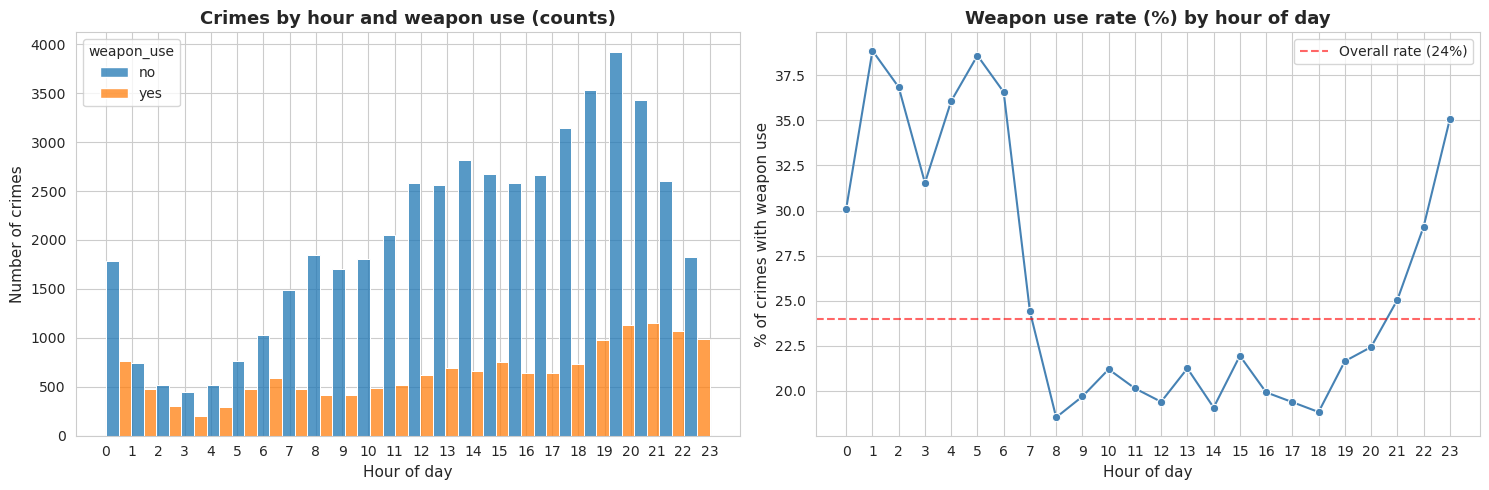

In [17]:
# Crimes per hour vs weapon use
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Left: histograms of hour
sns.histplot(data = crime, x = 'hour', hue = 'weapon_use',
             multiple = 'dodge', bins = 24, ax = axes[0])
axes[0].set_title('Crimes by hour and weapon use (counts)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Number of crimes')
axes[0].set_xticks(range(0, 24))

# Right: weapon use rate (%) per hour
weapon_rate_by_hour = (crime.groupby('hour')['weapon_use']
                            .apply(lambda x: (x == 'yes').mean() * 100))

sns.lineplot(x = weapon_rate_by_hour.index, y = weapon_rate_by_hour.values,
             marker = 'o', ax = axes[1], color = 'steelblue')
axes[1].axhline(y = 24, color = 'red', linestyle = '--', alpha = 0.6,
                label = 'Overall rate (24%)')
axes[1].set_title('Weapon use rate (%) by hour of day')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('% of crimes with weapon use')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.show()

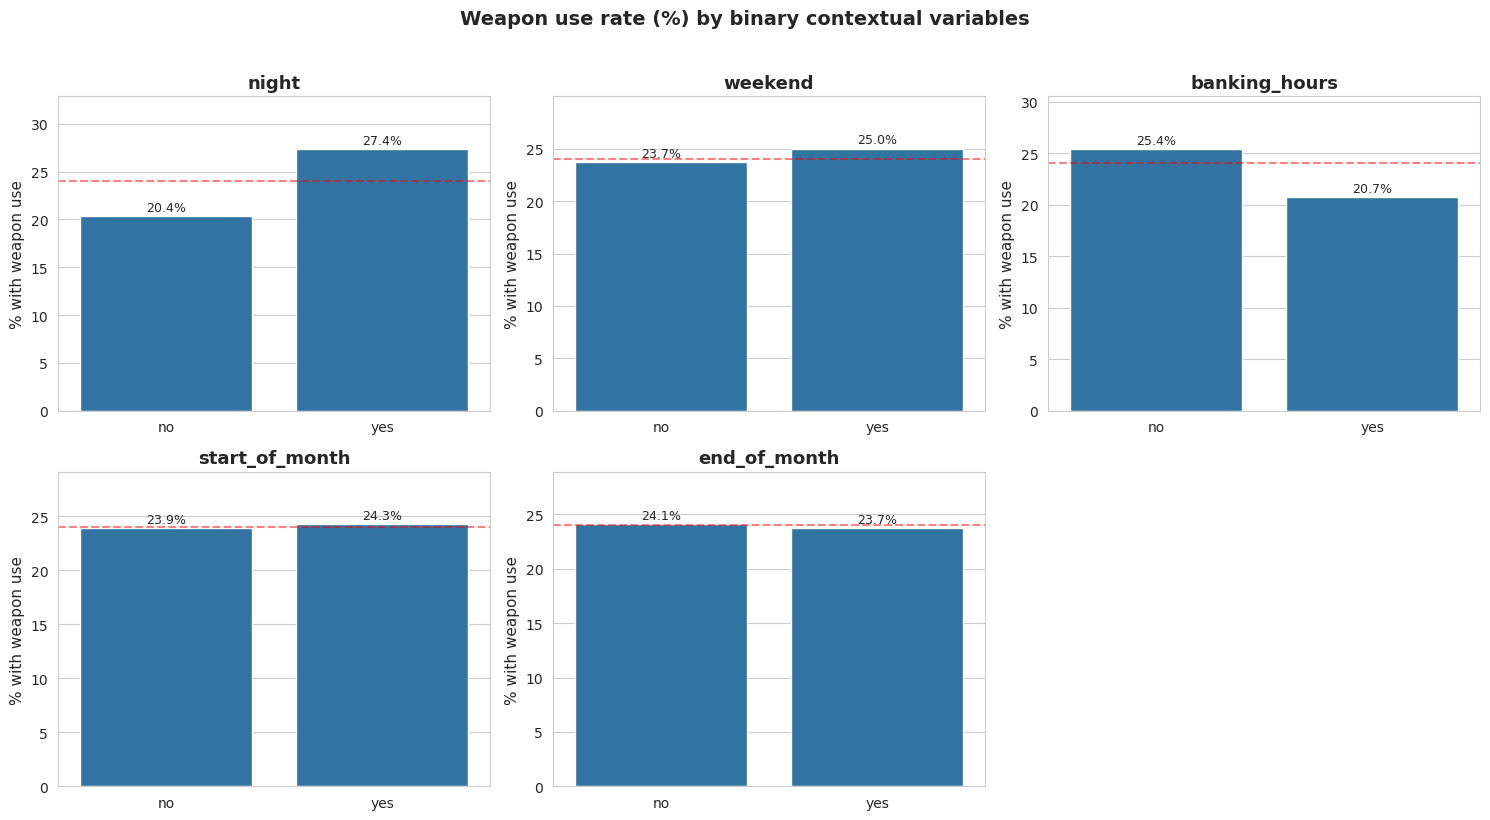

In [30]:
binary_vars = [
    'night', 'weekend', 'banking_hours', 'start_of_month', 'end_of_month',
]

# Compute weapon use rate for each variable
overall_rate = (crime['weapon_use'] == 'yes').mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(15, 8))   # ← cambio: 2x3 en vez de 3x4
axes = axes.flatten()

for i, var in enumerate(binary_vars):
    rate = (crime.groupby(var)['weapon_use']
                 .apply(lambda x: (x == 'yes').mean() * 100)
                 .reindex(['no', 'yes']))

    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% with weapon use')
    axes[i].axhline(y=overall_rate, color='red', linestyle='--',
                    alpha=0.5, label=f'Overall ({overall_rate:.0f}%)')
    axes[i].set_ylim(0, max(rate.values) * 1.2)

    # Add value labels
    for j, val in enumerate(rate.values):
        axes[i].text(j, val + 0.5, f'{val:.1f}%',
                     ha='center', fontsize=9)

# Turn off the unused last subplot
axes[5].axis('off')

plt.suptitle('Weapon use rate (%) by binary contextual variables',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

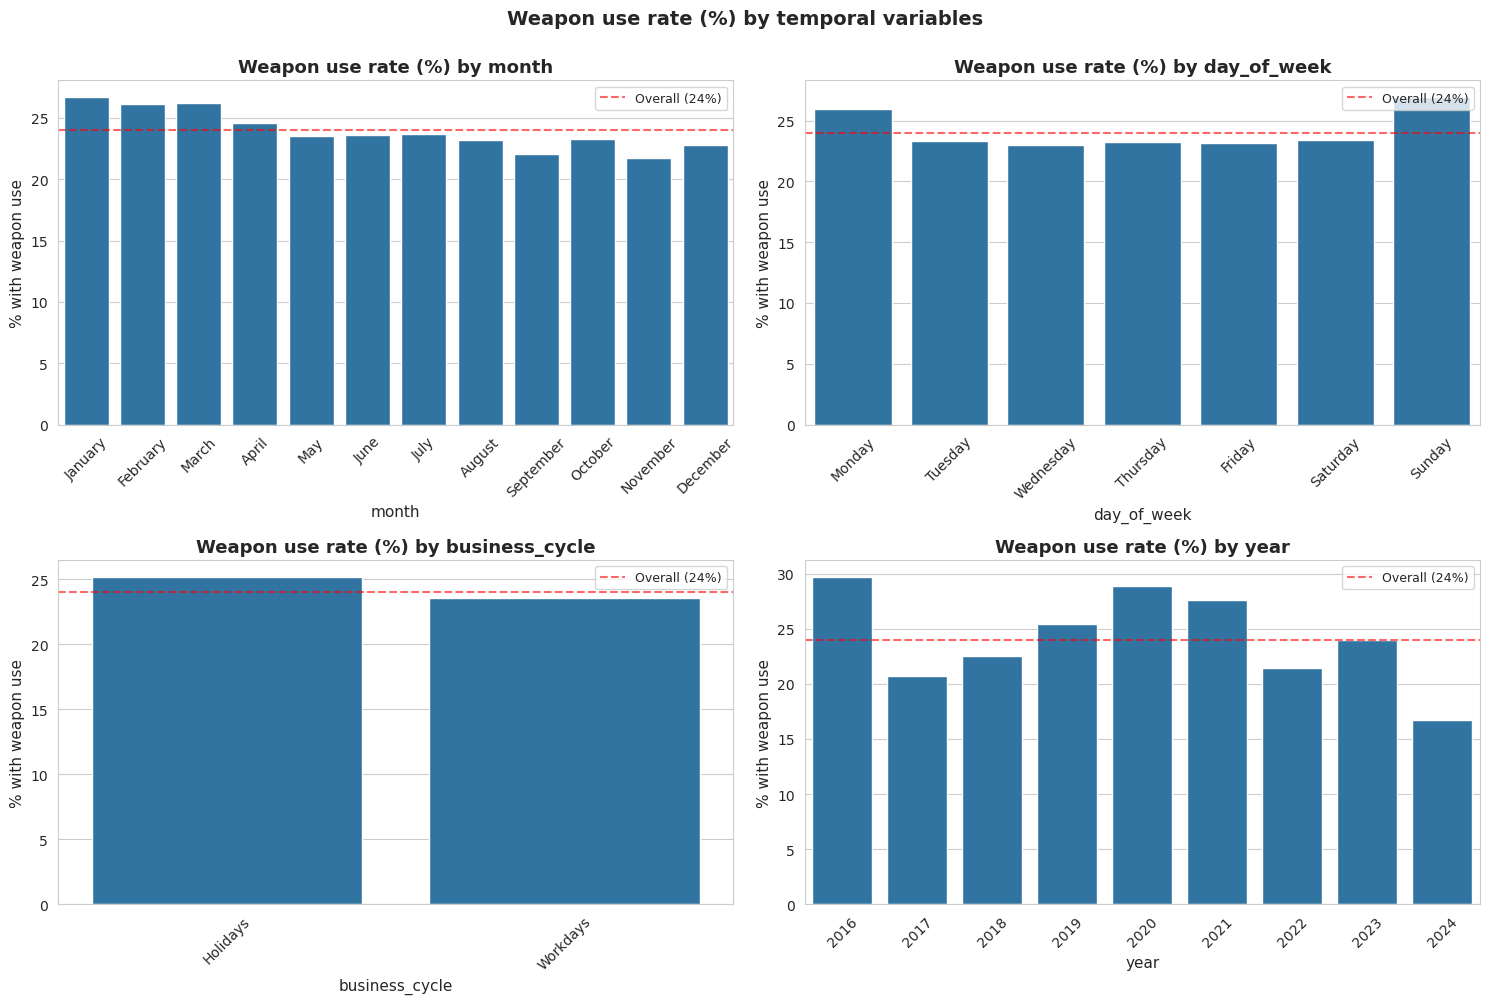

In [36]:
# Temporal variables vs weapon use rate
overall_rate = (crime['weapon_use'] == 'yes').mean() * 100

# Define correct ordering for ordinal variables
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

vars_to_plot = [
    ('month', month_order),
    ('day_of_week', dow_order),
    ('business_cycle', None),    # Will use frequency order
    ('year', None),              # Will use natural numeric order
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (var, custom_order) in enumerate(vars_to_plot):
    rate = (crime.groupby(var)['weapon_use']
                 .apply(lambda x: (x == 'yes').mean() * 100))

    if custom_order is not None:
        rate = rate.reindex(custom_order)
    elif var == 'year':
        rate = rate.sort_index() 

    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].axhline(y=overall_rate, color='red', linestyle='--',
                    alpha=0.6, label=f'Overall ({overall_rate:.0f}%)')
    axes[i].set_title(f'Weapon use rate (%) by {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('% with weapon use')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='upper right', fontsize=9)

plt.suptitle('Weapon use rate (%) by temporal variables',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

The frequency of crimes increases steadily from 3 AM until its peak around 8 PM, and then declines. The night time shows the highest proportion of crimes involving weapon use, consistent with Cohen & Felson (1979), but negatively correlated with `banking_hours`. Weapon usage seems to decrease since the pandemic.

#### - Crime type

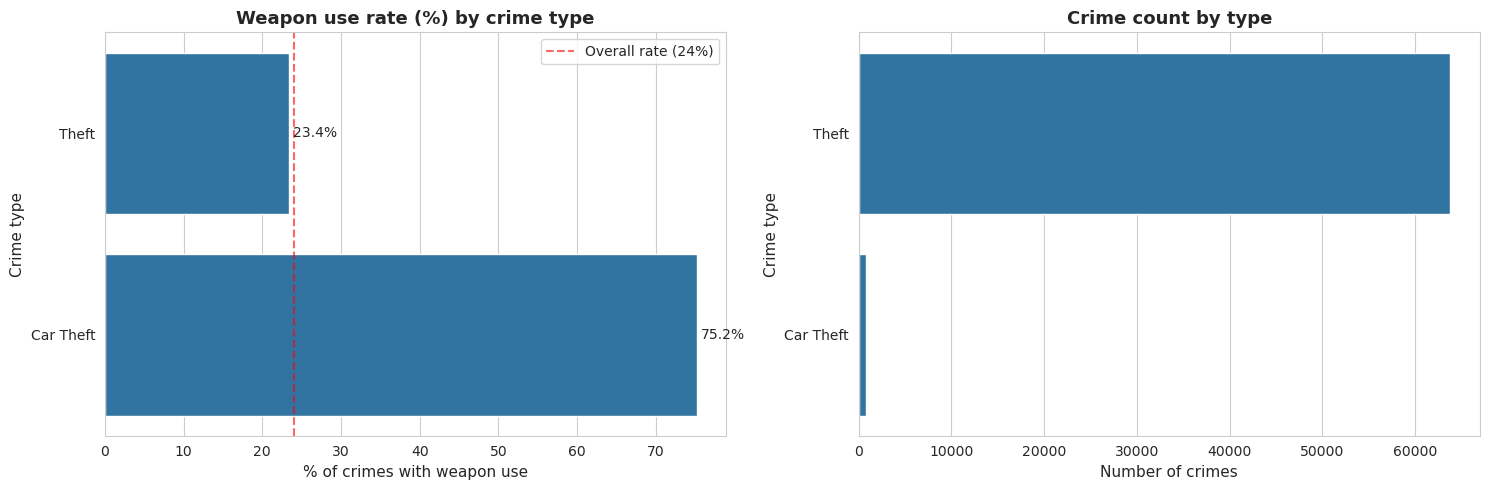

In [31]:
# Crime type vs weapon use rate
weapon_rate_by_type = (crime.groupby('crime_type')['weapon_use']
                            .apply(lambda x: (x == 'yes').mean() * 100)
                            .sort_values(ascending=True))

# Compute total counts per crime type for context
counts_by_type = crime['crime_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: rate of weapon use per crime type
sns.barplot(x=weapon_rate_by_type.values,
            y=weapon_rate_by_type.index,
            orient='h', ax=axes[0])
axes[0].set_title('Weapon use rate (%) by crime type')
axes[0].set_xlabel('% of crimes with weapon use')
axes[0].set_ylabel('Crime type')
axes[0].axvline(x=24, color='red', linestyle='--',
                alpha=0.6, label='Overall rate (24%)')
axes[0].legend()

# labels.
for i, (rate, label) in enumerate(zip(weapon_rate_by_type.values,
                                       weapon_rate_by_type.index)):
    axes[0].text(rate + 0.5, i, f'{rate:.1f}%', va='center', fontsize=10)

# Right: absolute counts per crime type
sns.barplot(x=counts_by_type.values,
            y=counts_by_type.index,
            orient='h', ax=axes[1])
axes[1].set_title('Crime count by type')
axes[1].set_xlabel('Number of crimes')
axes[1].set_ylabel('Crime type')

plt.tight_layout()
plt.show()

The dataset contains only two crime categories: Car Theft is statistically rare but strongly associated with weapon use.

#### - Socioeconomic Variables

In [23]:
def plot_continuous_vs_target(df, var, target='weapon_use',
                                positive_class='yes',
                                overall_rate=24, n_bins=20):
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Drop rows with missing values for this variable
    df_clean = df.dropna(subset=[var]).copy()

    # Left panel: histograms by class
    sns.histplot(data=df_clean, x=var, hue=target,
                 multiple='dodge', bins=n_bins, ax=axes[0])
    axes[0].set_title(f'Crimes by {var} and weapon use (counts)')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Number of crimes')

    # Right panel: rate of positive class along bins of the variable
    df_clean['_bin'] = pd.cut(df_clean[var], bins=n_bins)
    rate_by_bin = (df_clean.groupby('_bin', observed=True)[target]
                            .apply(lambda x: (x == positive_class).mean() * 100))

    bin_midpoints = [interval.mid for interval in rate_by_bin.index]

    sns.lineplot(x=bin_midpoints, y=rate_by_bin.values,
                 marker='o', ax=axes[1], color='steelblue')
    axes[1].axhline(y=overall_rate, color='red', linestyle='--', alpha=0.6,
                    label=f'Overall rate ({overall_rate}%)')
    axes[1].set_title(f'Weapon use rate (%) by {var}')
    axes[1].set_xlabel(var)
    axes[1].set_ylabel('% of crimes with weapon use')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

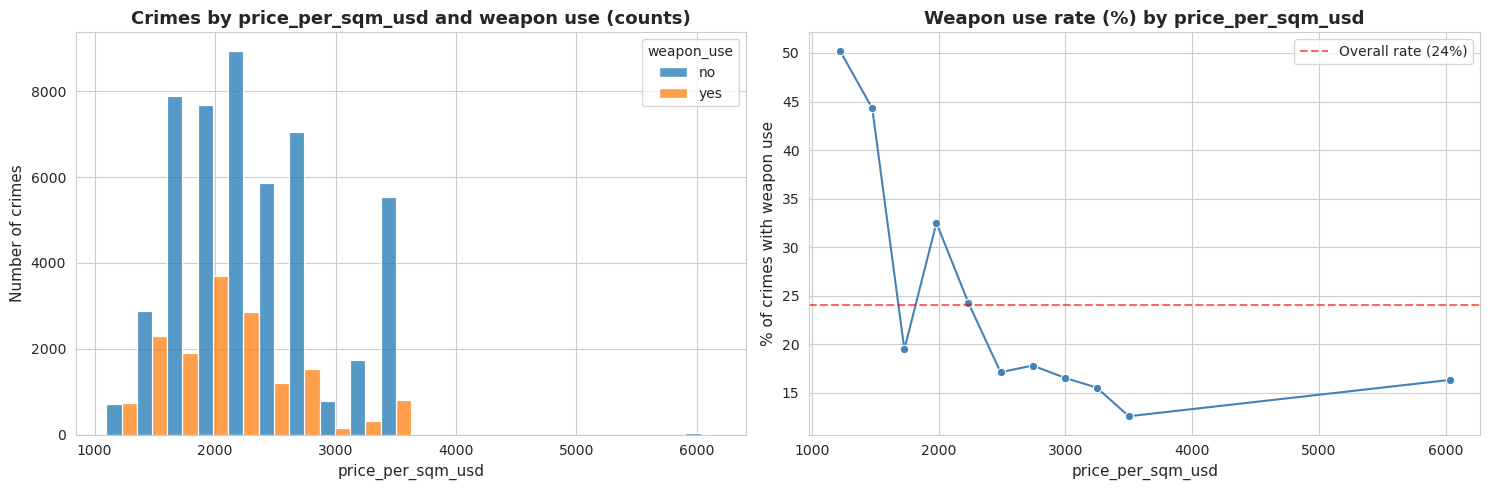

In [24]:
# Crimes per squaremeter value.
plot_continuous_vs_target(crime, var='price_per_sqm_usd', n_bins=20)

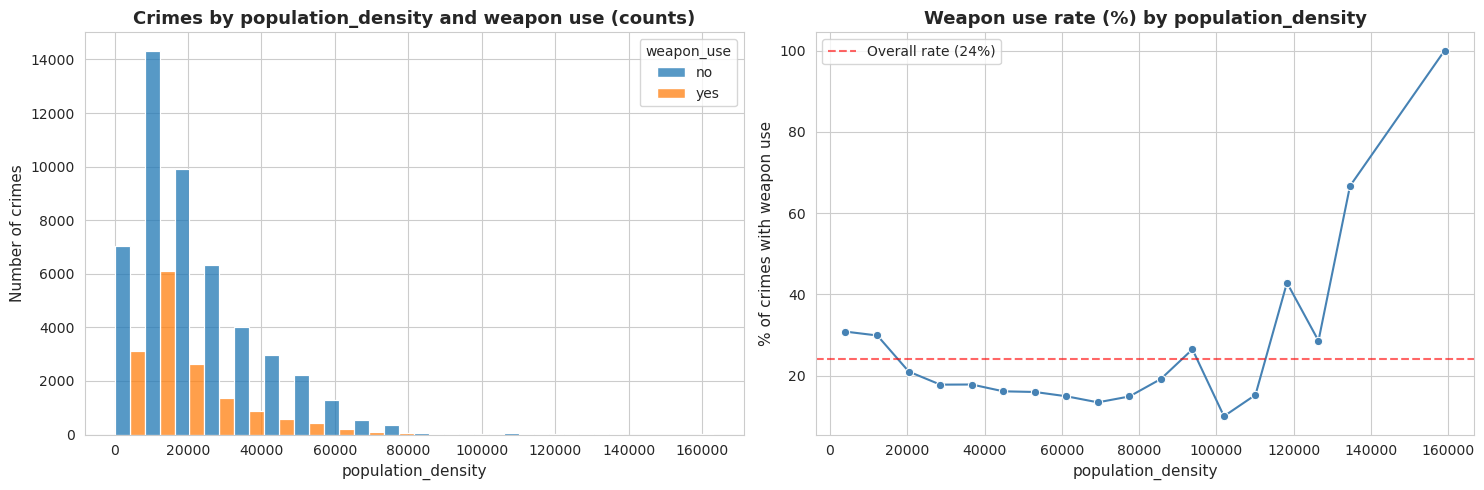

In [25]:
# Crimes per population density.
plot_continuous_vs_target(crime, var='population_density', n_bins=20)

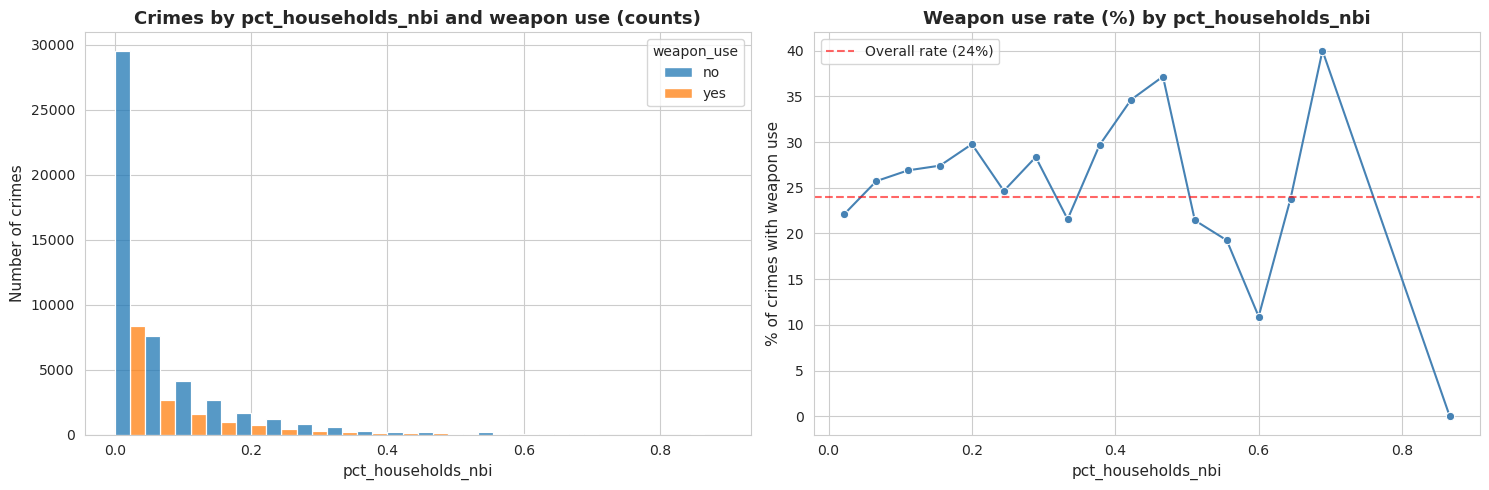

In [16]:
# Crimes by nbi
plot_continuous_vs_target(crime, var='pct_households_nbi', n_bins=20)

Weapon use rates drop with real estate price, increase with NBI, and follow a U-shaped pattern with population density in line with Bernasco and Block (2011).

#### - Built Environment

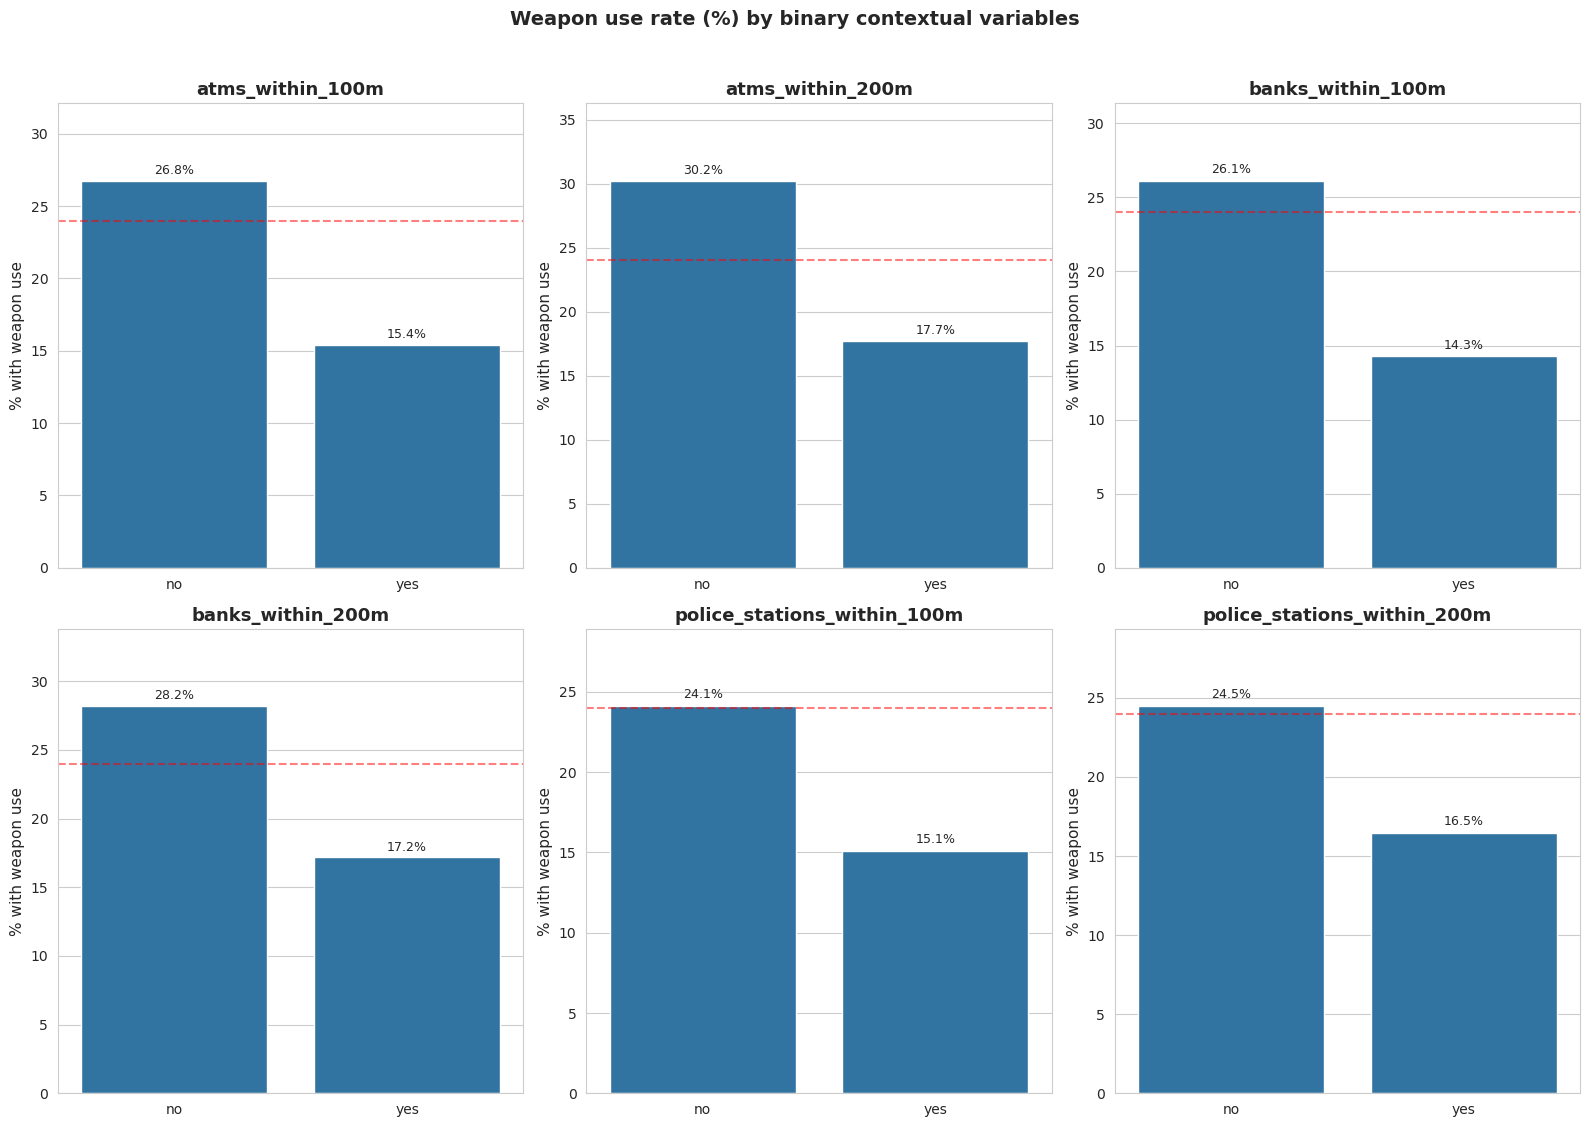

In [34]:
# Built environment vs weapon use
binary_vars = [
    'atms_within_100m', 'atms_within_200m',
    'banks_within_100m', 'banks_within_200m',
    'police_stations_within_100m', 'police_stations_within_200m'
]

# Compute weapon use rate for each variable
overall_rate = (crime['weapon_use'] == 'yes').mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for i, var in enumerate(binary_vars):
    rate = (crime.groupby(var)['weapon_use']
                 .apply(lambda x: (x == 'yes').mean() * 100)
                 .reindex(['no', 'yes']))  # ← AJUSTADO a minúsculas

    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% with weapon use')
    axes[i].axhline(y=overall_rate, color='red', linestyle='--',
                    alpha=0.5, label=f'Overall ({overall_rate:.0f}%)')
    axes[i].set_ylim(0, max(rate.values) * 1.2)

    # Add value labels 
    for j, val in enumerate(rate.values):
        axes[i].text(j, val + 0.5, f'{val:.1f}%',
                     ha='center', fontsize=9)

plt.suptitle('Weapon use rate (%) by binary contextual variables',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Proximity to ATMs, banks and police stations is associated with **lower** weapon use rates. The negative effect of police stations is consistent with deterrent effect (Di Tella & Schargrodsky, 2004). The negative association with ATMs and banks, by contrast, is **counterintuitive**.

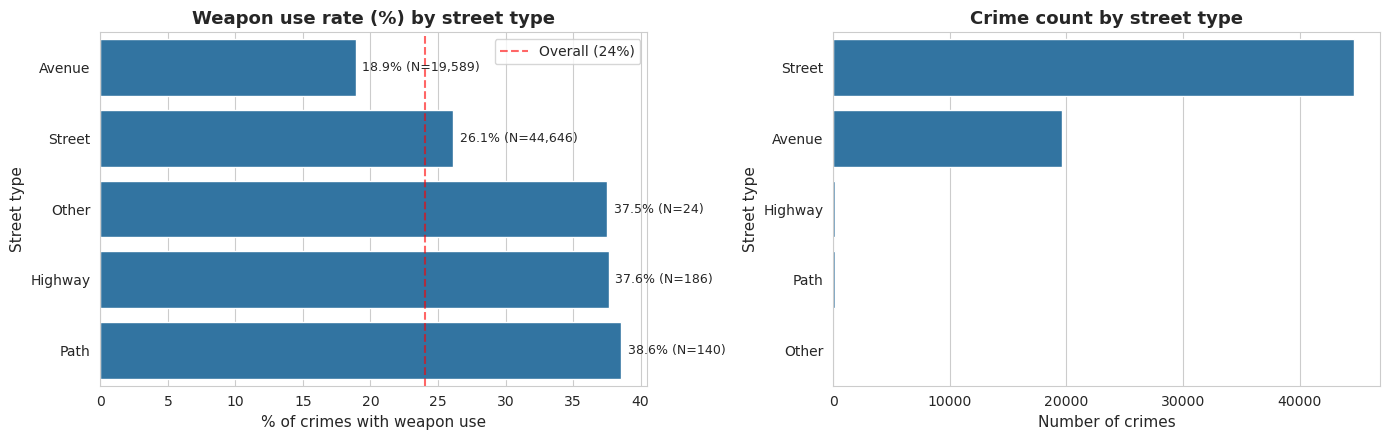

In [37]:
# Street type vs weapon use rate
counts_st = crime['street_type'].value_counts()
rates_st = (crime.groupby('street_type')['weapon_use']
                  .apply(lambda x: (x == 'yes').mean() * 100)
                  .sort_values(ascending=True))

overall_rate = (crime['weapon_use'] == 'yes').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: rate by street type
sns.barplot(x=rates_st.values, y=rates_st.index, orient='h', ax=axes[0])
axes[0].axvline(x=overall_rate, color='red', linestyle='--',
                alpha=0.6, label=f'Overall ({overall_rate:.0f}%)')
axes[0].set_title('Weapon use rate (%) by street type')
axes[0].set_xlabel('% of crimes with weapon use')
axes[0].set_ylabel('Street type')
axes[0].legend()

# Add labels
for i, (rate, label) in enumerate(zip(rates_st.values, rates_st.index)):
    n = counts_st[label]
    axes[0].text(rate + 0.5, i, f'{rate:.1f}% (N={n:,})',
                 va='center', fontsize=9)

# Right: counts
sns.barplot(x=counts_st.values, y=counts_st.index, orient='h', ax=axes[1])
axes[1].set_title('Crime count by street type')
axes[1].set_xlabel('Number of crimes')
axes[1].set_ylabel('Street type')

plt.tight_layout()
plt.show()

Pathways, bridges and highways show weapon use rates considerably higher than streets or avenues, a pattern aligned with on the role of the road hierarchy in shaping crime opportunities (Brantingham & Brantingham, 1995).

Finally, we compute a Spearman rank correlation matrix across numeric and binary variables. Spearman is preferred over Pearson because several variables are not normally distributed and is more robust to outliers. The aim is detecting potential redundancy.

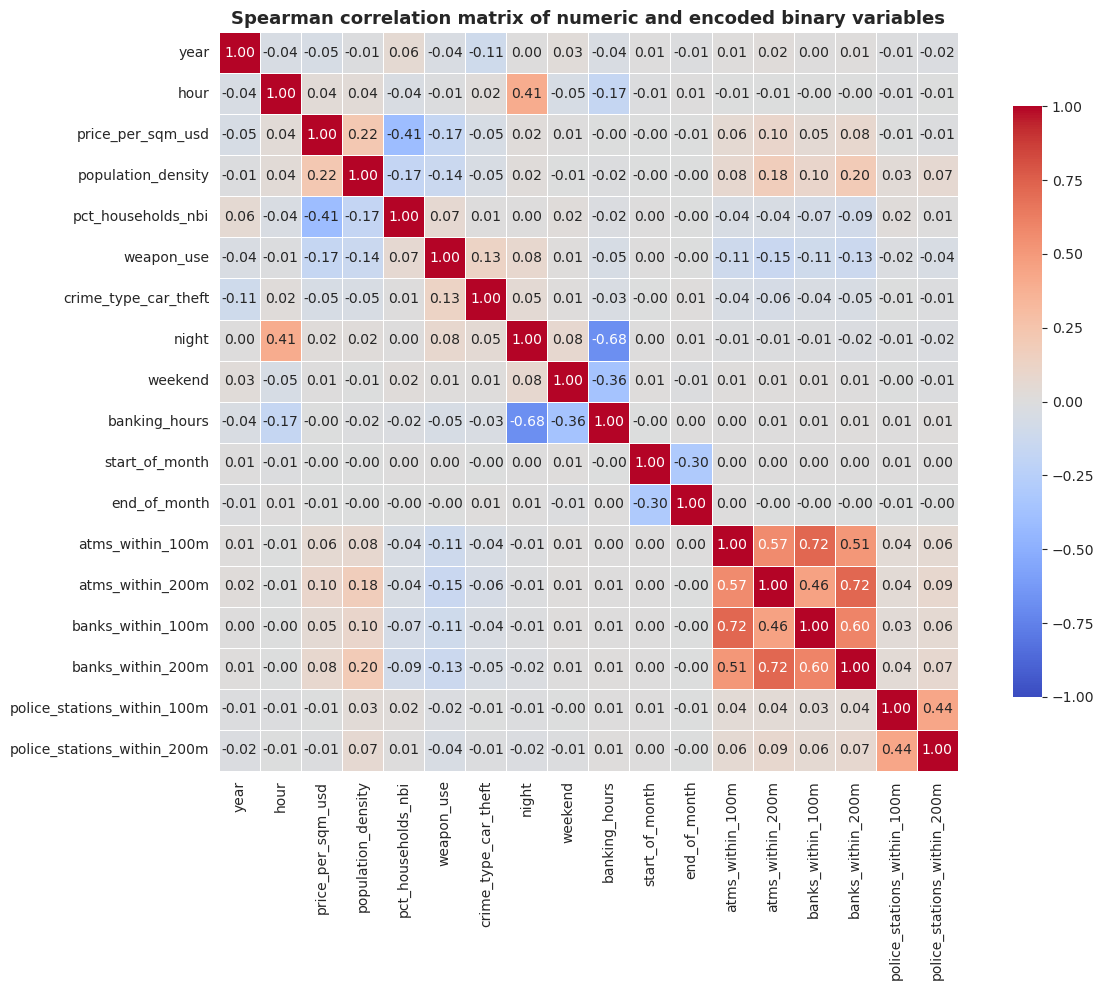

In [38]:
# Build a numeric-only copy for correlation analysis
crime_corr = crime.copy()

# Encode binary 'no'/'yes' columns as 0/1
binary_cols = [
    'weapon_use', 'night', 'weekend', 'banking_hours',
    'start_of_month', 'end_of_month',
    'atms_within_100m', 'atms_within_200m',
    'banks_within_100m', 'banks_within_200m',
    'police_stations_within_100m', 'police_stations_within_200m'
]
for col in binary_cols:
    crime_corr[col] = (crime_corr[col] == 'yes').astype(int)

# Encode crime_type as binary (Car Theft = 1, Theft = 0)
crime_corr['crime_type_car_theft'] = (crime_corr['crime_type'] == 'Car Theft').astype(int)

# Numeric columns to include
numeric_cols = [
    'year', 'hour',
    'price_per_sqm_usd', 'population_density', 'pct_households_nbi',
    'weapon_use', 'crime_type_car_theft',
    'night', 'weekend', 'banking_hours',
    'start_of_month', 'end_of_month',
    'atms_within_100m', 'atms_within_200m',
    'banks_within_100m', 'banks_within_200m',
    'police_stations_within_100m', 'police_stations_within_200m'
]

# Spearman correlation matrix
corr = crime_corr[numeric_cols].corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Spearman correlation matrix of numeric and encoded binary variables",
          fontsize=13)
plt.tight_layout()
plt.show()

The correlation matrix reveals strong redundancies among proximity variables and between `night` and `banking_hours` suggesting that one indicator per group is sufficient. Correlations with the target (`weapon_use`) are modest but coherent in direction. 

### Variable description

| Variable | Description | Type | Source | Spatial unit | Used in model |
|---|---|---|---|---|---|
| `weapon_use` | Whether a weapon was used in the crime (target variable) | Binary (yes/no) | BA Data — Crimes | Point | Target |
| `year` | Year of the event | Numeric (2016–2024) | BA Data — Crimes | Point | ✓ |
| `month` | Month of the event | Categorical (12) | BA Data — Crimes | Point | ✓ |
| `day` | Day of the month | Numeric (1–31) | BA Data — Crimes | Point | ✗ (Discarded after exploratory analysis) |
| `day_of_week` | Day of the week | Categorical (7) | BA Data — Crimes | Point | ✗ (Discarded after exploratory analysis) |
| `weekend` | Whether the event occurred on a weekend | Binary | Derived | Point | ✗ (Discarded after exploratory analysis) |
| `start_of_month` | Whether the event occurred in the first 7 days of the month | Binary | Derived | Point | ✗ (Discarded after exploratory analysis) |
| `end_of_month` | Whether the event occurred in the last 7 days of the month | Binary | Derived | Point | ✗ (Discarded after exploratory analysis) |
| `business_cycle` | Workdays vs holidays classification | Categorical | Derived | Point | ✗ (Discarded after exploratory analysis) |
| `hour` | Hour of the event (0–23) | Numeric | BA Data — Crimes | Point | ✓ |
| `night` | Whether the event occurred at night (19:00–06:00) | Binary | Derived | Point | ✓ |
| `banking_hours` | Whether the event occurred during banking hours (10:00 - 18:00) | Binary | Derived | Point | ✗ (redundant with `night`) |
| `crime_type` | Crime classification (Theft / Car Theft) | Categorical (2) | BA Data — Crimes | Point | ✓ |
| `street_type` | Type of public way (Street, Avenue, Highway, etc.) | Categorical | BA Data — Crimes | Point | ✓ |
| `atms_within_100m` | Whether at least one ATM is within 100m | Binary | BA Data — ATMs | Point | ✗ (redundant with 200m) |
| `atms_within_200m` | Whether at least one ATM is within 200m | Binary | BA Data — ATMs | Point | ✓ |
| `atm_bank` | Bank operating the nearest ATM | Categorical (high cardinality) | BA Data — ATMs | Point | ✗ (Discarded for model simplicity) |
| `atm_network` | ATM network of the nearest ATM | Categorical | BA Data — ATMs | Point | ✗ (Discarded for model simplicity) |
| `banks_within_100m` | Whether at least one bank is within 100m | Binary | BA Data — Banks | Point | ✗ (redundant with 200m) |
| `banks_within_200m` | Whether at least one bank is within 200m | Binary | BA Data — Banks | Point | ✓ |
| `police_stations_within_100m` | Whether at least one police station is within 100m | Binary | BA Data — Police stations | Point | ✗ (redundant with 200m) |
| `police_stations_within_200m` | Whether at least one police station is within 200m | Binary | BA Data — Police stations | Point | ✓ |
| `price_per_sqm_usd` | Real estate price per square metre (USD) | Numeric | BA Data — Real estate | Neighbourhood | ✓ |
| `population_density` | Population density (inhabitants per census tract area) | Numeric | INDEC / BA Data | Census tract | ✓ |
| `pct_households_nbi` | Proportion of households with Unsatisfied Basic Needs (0–1) | Numeric | INDEC / BA Data | Census tract | ✓ |
| `neighbourhood` | Neighbourhood name (48 categories) | Categorical | BA Data — Crimes | Point | ✗ (covered by socioeconomic variables) |
| `commune` | Commune number (15 categories) | Categorical | BA Data — Crimes | Point | ✗ (covered by socioeconomic variables) |

## Methodology

[[ go back to the top ]](#Table-of-contents)

We approach the prediction of weapon use as a **binary classification task**, evaluated through a stratified 80/20 train/test split with a `ColumnTransformer` preprocessing pipeline (median/most-frequent imputation, one-hot encoding, standardisation) to prevent data leakage.

We compare three models of increasing complexity:

+ **Logistic Regression** (Benchmark)
+ **Random Forest**
+ **XGBoost**

We handle moderate class imbalance (76/24) via `class_weight='balanced'` and `scale_pos_weight`, and prioritising **recall on the positive class** as the optimisation metric in 5-fold cross-validation. 

Finally, after an initial XGBoost run, we apply **Mutual Information** and **Permutation Importance** to refine the feature set, retraining XGBoost on the reduced subset (8 of 12 features). To conclude, **SHAP values** are used to interpret the final model at both global and per-instance levels.


In [43]:
# We arrange data into a features matrix and target vector
# Before we define the feature set, we categorize the variables.
numeric_features = [
    'year', 'hour',
    'price_per_sqm_usd', 'population_density', 'pct_households_nbi'
]

categorical_features = [
    'month', 'street_type', 'crime_type'
]

binary_features = [
    'night',
    'atms_within_200m',
    'banks_within_200m',
    'police_stations_within_200m'
]

# Combine into the full feature list
features = numeric_features + categorical_features + binary_features

# Features Matrix
X = crime[features].copy()
# Target Vector - As `weapon_use == 'yes'` is the minority class and the class of interest, encoded as 1.
y = (crime['weapon_use'] == 'yes').astype(int) 

# Summary
print(f"Dataset shape: {X.shape[0]} samples × {X.shape[1]} features")
print("Class proportions:")
print((class_counts / len(y)).rename(index={0: "Class 0", 1: "Class 1"}).round(4))

print(f"\nNumber of features: {X.shape[1]}")
print("Feature names:")
print(X.columns.tolist())

Dataset shape: 64585 samples × 12 features
Class proportions:
weapon_use
Class 0    0.76
Class 1    0.24
Name: count, dtype: float64

Number of features: 12
Feature names:
['year', 'hour', 'price_per_sqm_usd', 'population_density', 'pct_households_nbi', 'month', 'street_type', 'crime_type', 'night', 'atms_within_200m', 'banks_within_200m', 'police_stations_within_200m']


In [45]:
# We perform a stratified 80/20 split.
# It preserves the 76/24 class proportion in both training and test sets, which is essential given the moderate class imbalance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,
    random_state = RANDOM_STATE,
    stratify = y
)

print(f"Train shape: {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"Test shape:  {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

print(f"\nClass proportion preserved:")
print(f"  Train: {y_train.mean():.1%}")
print(f"  Test:  {y_test.mean():.1%}")

Train shape: 51,668 samples × 12 features
Test shape:  12,917 samples × 12 features

Class proportion preserved:
  Train: 24.0%
  Test:  24.0%


In [46]:
# We follow sklearn pipeline. This handles imputation, encoding and scaling consistently between training and prediction.
# Note: standardisation is applied only to numeric features (relevant for Logistic Regression).
# Tree-based models are scale-invariant, but we keep the same preprocessing for consistency like we've seen in class.

# First, we convert binary features ("yes"/"no") into 1/0.
# This is done outside the ColumnTransformer because OneHotEncoder would create
# redundant dummies (one for each category) for already-binary indicators.
for col in binary_features:
    X_train[col] = (X_train[col] == 'yes').astype(int)
    X_test[col]  = (X_test[col]  == 'yes').astype(int)

# We imput missing values according to numeric and categorical features.
# Numerical features: median imputation + standardisation
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler",  StandardScaler())
])

# Categorical features: mode imputation + one-hot encoding
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")), # Mode
    ("onehot",  OneHotEncoder(handle_unknown = "ignore"))
])

# Binary: mode imputation only (already 0/1, no scaling needed)
binary_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])


# We combine into a single ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("bin", binary_pipe, binary_features),
    ("cat", categorical_pipe, categorical_features)
])


print(f"Preprocessor configured with {len(numeric_features)} numeric, "
      f"{len(binary_features)} binary, and {len(categorical_features)} categorical features.")

Preprocessor configured with 5 numeric, 4 binary, and 3 categorical features.


In [48]:
# Finally, we define a reusable helper function used to summarise model performance 
# across the three models.

def summarise_performance(y_true, y_pred, y_proba):
    """Return a dict of key classification metrics for the positive class.
    Accuracy is omitted because of the moderate class imbalance.
    """
    return {
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_proba)
    }


### Model 1: Logistic Regression (baseline)


In [47]:
# Logistic Regression model wrapped in the full pipeline.
# Because of the moderate class imbalance, we use `class_weight='balanced'` to weight observations inversely proportional to class frequencies. 
log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter = 1000,
        class_weight = 'balanced',
        random_state = RANDOM_STATE
    ))
])

# Train on the training set
log_reg.fit(X_train, y_train)

# Verify convergence
n_iter = log_reg.named_steps["classifier"].n_iter_[0]
print(f"Logistic Regression converged in {n_iter} iterations (max_iter=1000)")

Logistic Regression converged in 41 iterations (max_iter=1000)


In [49]:
# Predict on both train and test sets
y_pred_train_lr  = log_reg.predict(X_train)
y_pred_test_lr   = log_reg.predict(X_test)
y_proba_train_lr = log_reg.predict_proba(X_train)[:, 1]
y_proba_test_lr  = log_reg.predict_proba(X_test)[:, 1]

# Compute metrics on train and test using the helper defined earlier
train_metrics = summarise_performance(y_train, y_pred_train_lr, y_proba_train_lr)
test_metrics  = summarise_performance(y_test,  y_pred_test_lr,  y_proba_test_lr)

# Side-by-side comparison + detailed report
results_lr = pd.DataFrame({
    'Train':        train_metrics,
    'Test':         test_metrics,
    'Train - Test': {k: train_metrics[k] - test_metrics[k] for k in train_metrics}
}).round(3)

print("=== Logistic Regression — Train vs Test performance ===\n")
print(results_lr)

print("\n--- Detailed test set classification report ---")
print(classification_report(y_test, y_pred_test_lr,
                            target_names=['No weapon', 'Weapon use'],
                            digits=3))

=== Logistic Regression — Train vs Test performance ===

           Train   Test  Train - Test
precision  0.353  0.351         0.001
recall     0.646  0.629         0.017
f1         0.456  0.451         0.006
roc_auc    0.684  0.675         0.008

--- Detailed test set classification report ---
              precision    recall  f1-score   support

   No weapon      0.844     0.633     0.723      9817
  Weapon use      0.351     0.629     0.451      3100

    accuracy                          0.632     12917
   macro avg      0.597     0.631     0.587     12917
weighted avg      0.726     0.632     0.658     12917



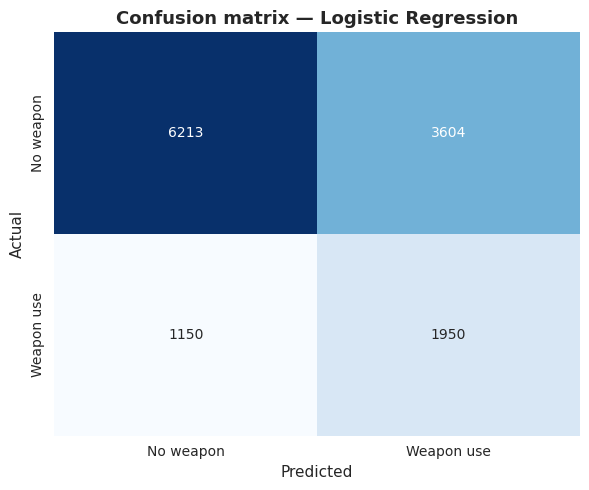

In [50]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No weapon', 'Weapon use'],
            yticklabels=['No weapon', 'Weapon use'],
            cbar=False)
plt.title('Confusion matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [32]:
# We inspect the standardised coefficients of the Logistic Regression model.
# A positive coefficient indicates that increasing the feature value (for numeric features) 
# or the presence of the category (for binary/categorical features) raises the predicted probability of weapon use
# First, we extract trained classifier and feature names
classifier = log_reg.named_steps['classifier']
feature_names = log_reg.named_steps['preprocessor'].get_feature_names_out()

# Build a DataFrame with coefficients
coefs = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': classifier.coef_[0]
}).sort_values('coefficient', ascending=False)

# Show top positive and top negative
print("=== Top 10 features pushing toward 'Weapon use' (positive coefficients) ===")
print(coefs.head(10).to_string(index=False))

print("\n=== Top 10 features pushing toward 'No weapon' (negative coefficients) ===")
print(coefs.tail(10).to_string(index=False))

=== Top 10 features pushing toward 'Weapon use' (positive coefficients) ===
                  feature  coefficient
cat__crime_type_Car Theft     1.158599
    cat__street_type_Path     0.577781
               bin__night     0.454542
 cat__street_type_Highway     0.293451
       cat__month_January     0.183675
      cat__month_February     0.152784
         cat__month_March     0.145965
         cat__month_April     0.104685
          cat__month_June     0.043497
          cat__month_July     0.030779

=== Top 10 features pushing toward 'No weapon' (negative coefficients) ===
                         feature  coefficient
             cat__month_December    -0.050122
                       num__year    -0.103013
          bin__banks_within_200m    -0.108800
                       num__hour    -0.137861
         num__population_density    -0.189934
         cat__street_type_Avenue    -0.327539
          num__price_per_sqm_usd    -0.349708
bin__police_stations_within_200m    -0.352480
     

**Results**:

The model achieves modest performance on the positive class. The very small train-test gap confirms good generalization. The recall is comparable across the two classes due to weight balance. This baseline establishes the lower bound of what context-only features can achieve under a linear assumption. 


### Model 2: Random Forest


In [51]:
# We train a Random Forest classifier and tune its hyperparameters using 5-fold cross-validation with `GridSearchCV`.
# The hyperparameters considered are `max_depth`, `min_samples_leaf` and `max_features`.
# The optimisation metric is **recall** on the positive class (`weapon_use = yes`), prioritising the detection of actual weapon-involved crimes.

# Random Forest v1: initial grid search to identify the optimal hyperparameter region
rf_pipe_v1 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Hyperparameter grid: max_depth, min_samples_leaf, max_features
param_grid_rf_v1 = {
    'classifier__max_depth':        [10, 20, None],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__max_features':     ['sqrt', 0.5]
}

# 5-fold stratified CV with recall as the scoring metric
grid_rf_v1 = GridSearchCV(
    estimator=rf_pipe_v1,
    param_grid=param_grid_rf_v1,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

print("Starting Random Forest grid search (v1)... this may take 5-15 minutes.")
grid_rf_v1.fit(X_train, y_train)

print("\n=== Best hyperparameters (RF v1) ===")
print(grid_rf_v1.best_params_)
print(f"\nBest CV recall: {grid_rf_v1.best_score_:.3f}")

Starting Random Forest grid search (v1)... this may take 5-15 minutes.
Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Best hyperparameters (RF v1) ===
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4}

Best CV recall: 0.602


In [53]:
# Evaluate the best Random Forest (v1) on train and test
best_rf_v1 = grid_rf_v1.best_estimator_

y_pred_train_rf_v1  = best_rf_v1.predict(X_train)
y_pred_test_rf_v1   = best_rf_v1.predict(X_test)
y_proba_train_rf_v1 = best_rf_v1.predict_proba(X_train)[:, 1]
y_proba_test_rf_v1  = best_rf_v1.predict_proba(X_test)[:, 1]

train_metrics_rf_v1 = summarise_performance(y_train, y_pred_train_rf_v1, y_proba_train_rf_v1)
test_metrics_rf_v1  = summarise_performance(y_test,  y_pred_test_rf_v1,  y_proba_test_rf_v1)

results_rf_v1 = pd.DataFrame({
    'Train':        train_metrics_rf_v1,
    'Test':         test_metrics_rf_v1,
    'Train - Test': {k: train_metrics_rf_v1[k] - test_metrics_rf_v1[k] for k in train_metrics_rf_v1}
}).round(3)

print("=== Random Forest v1 — Train vs Test performance ===\n")
print(results_rf_v1)

print("\n--- Detailed test set classification report ---")
print(classification_report(y_test, y_pred_test_rf_v1,
                            target_names=['No weapon', 'Weapon use'],
                            digits=3))

=== Random Forest v1 — Train vs Test performance ===

           Train   Test  Train - Test
precision  0.419  0.393         0.026
recall     0.653  0.598         0.056
f1         0.511  0.475         0.036
roc_auc    0.755  0.709         0.046

--- Detailed test set classification report ---
              precision    recall  f1-score   support

   No weapon      0.848     0.709     0.772      9817
  Weapon use      0.393     0.598     0.475      3100

    accuracy                          0.682     12917
   macro avg      0.621     0.653     0.623     12917
weighted avg      0.739     0.682     0.701     12917



In [55]:
# Hyperparameter refinement: The initial grid search identified `max_depth=10`, `min_samples_leaf=4`, `max_features='sqrt'`
# as the best combination to reduce overfitting while preserving recall.

param_grid_rf_v2 = {
    'classifier__max_depth':        [8, 10, 12, 15],
    'classifier__min_samples_leaf': [4, 8, 16],
    'classifier__max_features':     ['sqrt', 0.3]
}

grid_rf_v2 = GridSearchCV(
    estimator=rf_pipe_v1,
    param_grid=param_grid_rf_v2,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

print("Starting refined Random Forest grid search...")
grid_rf_v2.fit(X_train, y_train)

print("\n=== Best hyperparameters (refined) ===")
print(grid_rf_v2.best_params_)
print(f"\nBest CV recall: {grid_rf_v2.best_score_:.3f}")

Starting refined Random Forest grid search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Best hyperparameters (refined) ===
{'classifier__max_depth': 8, 'classifier__max_features': 0.3, 'classifier__min_samples_leaf': 16}

Best CV recall: 0.616


In [56]:
# Re-evaluate with refined model
best_rf_v2 = grid_rf_v2.best_estimator_

y_pred_train_rf_v2  = best_rf_v2.predict(X_train)
y_pred_test_rf_v2   = best_rf_v2.predict(X_test)
y_proba_train_rf_v2 = best_rf_v2.predict_proba(X_train)[:, 1]
y_proba_test_rf_v2  = best_rf_v2.predict_proba(X_test)[:, 1]

train_metrics_rf_v2 = summarise_performance(y_train, y_pred_train_rf_v2, y_proba_train_rf_v2)
test_metrics_rf_v2  = summarise_performance(y_test,  y_pred_test_rf_v2,  y_proba_test_rf_v2)

results_rf_v2 = pd.DataFrame({
    'Train':        train_metrics_rf_v2,
    'Test':         test_metrics_rf_v2,
    'Train - Test': {k: train_metrics_rf_v2[k] - test_metrics_rf_v2[k] for k in train_metrics_rf_v2}
}).round(3)

print("=== Random Forest v2 (refined) — Train vs Test performance ===\n")
print(results_rf_v2)

print("\n--- Detailed test set classification report ---")
print(classification_report(y_test, y_pred_test_rf_v2,
                            target_names=['No weapon', 'Weapon use'],
                            digits=3))

=== Random Forest v2 (refined) — Train vs Test performance ===

           Train   Test  Train - Test
precision  0.400  0.388         0.012
recall     0.642  0.612         0.030
f1         0.493  0.475         0.018
roc_auc    0.732  0.710         0.022

--- Detailed test set classification report ---
              precision    recall  f1-score   support

   No weapon      0.850     0.696     0.765      9817
  Weapon use      0.388     0.612     0.475      3100

    accuracy                          0.675     12917
   macro avg      0.619     0.654     0.620     12917
weighted avg      0.739     0.675     0.696     12917



**Results:**

The model achieves  a modest improvement over Logistic Regression on recall and ROC-AUC with no overfitting. The moderate gain suggests that part of the signal is non-linear but most is already captured by linear combinations.


### Model 3: XGBoost


In [57]:
# Our third model is XGBoost, a sequential gradient-boosted ensemble that, with proper tuning,
# often outperforms Random Forest on tabular data.
# We tune three key hyperparameters:
#   - max_depth: maximum depth of each tree (controls complexity)
#   - min_split_loss: minimum loss reduction required to make a further partition (regularisation)
#   - subsample: fraction of observations used to grow each tree (reduces overfitting)
# The optimisation metric remains recall on the positive class.
# To handle the moderate class imbalance, we use `scale_pos_weight`, XGBoost's native mechanism
# that weights the positive class by the ratio of negative to positive samples in the training set.

# Compute scale_pos_weight from training data
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# Pipeline
xgb_pipe_v1 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

# Hyperparameter grid (based on Class 4)
param_grid_xgb_v1 = {
    'classifier__max_depth':      [3, 5, 7],
    'classifier__min_split_loss': [0, 1, 5],
    'classifier__subsample':      [0.5, 0.7, 1.0]
}

# 5-fold stratified CV with recall as scoring metric
grid_xgb_v1 = GridSearchCV(
    estimator=xgb_pipe_v1,
    param_grid=param_grid_xgb_v1,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

print("Starting XGBoost grid search... this may take 5-15 minutes.")
grid_xgb_v1.fit(X_train, y_train)

print("\n=== Best hyperparameters (XGBoost v1) ===")
print(grid_xgb_v1.best_params_)
print(f"\nBest CV recall: {grid_xgb_v1.best_score_:.3f}")


scale_pos_weight = 3.17
Starting XGBoost grid search... this may take 5-15 minutes.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

=== Best hyperparameters (XGBoost v1) ===
{'classifier__max_depth': 3, 'classifier__min_split_loss': 1, 'classifier__subsample': 0.7}

Best CV recall: 0.642


In [58]:
# Evaluate the best XGBoost (v1) on train and test
best_xgb_v1 = grid_xgb_v1.best_estimator_

y_pred_train_xgb_v1  = best_xgb_v1.predict(X_train)
y_pred_test_xgb_v1   = best_xgb_v1.predict(X_test)
y_proba_train_xgb_v1 = best_xgb_v1.predict_proba(X_train)[:, 1]
y_proba_test_xgb_v1  = best_xgb_v1.predict_proba(X_test)[:, 1]

train_metrics_xgb_v1 = summarise_performance(y_train, y_pred_train_xgb_v1, y_proba_train_xgb_v1)
test_metrics_xgb_v1  = summarise_performance(y_test,  y_pred_test_xgb_v1,  y_proba_test_xgb_v1)

results_xgb_v1 = pd.DataFrame({
    'Train':        train_metrics_xgb_v1,
    'Test':         test_metrics_xgb_v1,
    'Train - Test': {k: train_metrics_xgb_v1[k] - test_metrics_xgb_v1[k] for k in train_metrics_xgb_v1}
}).round(3)

print("=== XGBoost v1 — Train vs Test performance ===\n")
print(results_xgb_v1)

print("\n--- Detailed test set classification report ---")
print(classification_report(y_test, y_pred_test_xgb_v1,
                            target_names=['No weapon', 'Weapon use'],
                            digits=3))

=== XGBoost v1 — Train vs Test performance ===

           Train   Test  Train - Test
precision  0.409  0.398         0.011
recall     0.668  0.641         0.026
f1         0.507  0.491         0.016
roc_auc    0.746  0.724         0.022

--- Detailed test set classification report ---
              precision    recall  f1-score   support

   No weapon      0.860     0.694     0.768      9817
  Weapon use      0.398     0.641     0.491      3100

    accuracy                          0.681     12917
   macro avg      0.629     0.667     0.629     12917
weighted avg      0.749     0.681     0.701     12917




### Feature Selection


In [60]:
### Mutual Information (MI)

# We apply MI to quantify the statistical dependence between each feature and the target.
# MI captures any kind of statistical dependence, including the non-linear and threshold-like patterns observed in the data exploration.
# We compute MI on the preprocessed feature matrix so that all features are on a common numeric basis. 
# The objective is to identify features for elimination in the next iteration of the model.


# Step 1: apply the preprocessor to X_train (re-fit to obtain the transformed array)
X_train_processed = preprocessor.fit_transform(X_train)
feature_names_processed = preprocessor.get_feature_names_out()


# Step 2: compute MI between each preprocessed feature and the target
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

# Step 3: build a DataFrame for inspection
mi_df = pd.DataFrame({
    'feature': feature_names_processed,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("=== Mutual Information scores (top 10) ===\n")
print(mi_df.head(10).to_string(index=False))

print("\n=== Bottom 10 (least informative) ===\n")
print(mi_df.tail(10).to_string(index=False))

=== Mutual Information scores (top 10) ===

                  feature  mi_score
  num__population_density  0.050472
  num__pct_households_nbi  0.042604
   num__price_per_sqm_usd  0.037528
    bin__atms_within_200m  0.017089
    cat__crime_type_Theft  0.016093
   bin__banks_within_200m  0.013690
               bin__night  0.009487
                num__hour  0.008083
  cat__street_type_Street  0.007539
cat__crime_type_Car Theft  0.005353

=== Bottom 10 (least informative) ===

                         feature  mi_score
           cat__street_type_Path  0.000714
              cat__month_January  0.000525
             cat__month_December  0.000000
                cat__month_April  0.000000
bin__police_stations_within_200m  0.000000
             cat__month_February  0.000000
              cat__month_October  0.000000
                cat__month_March  0.000000
          cat__street_type_Other  0.000000
        cat__street_type_Highway  0.000000


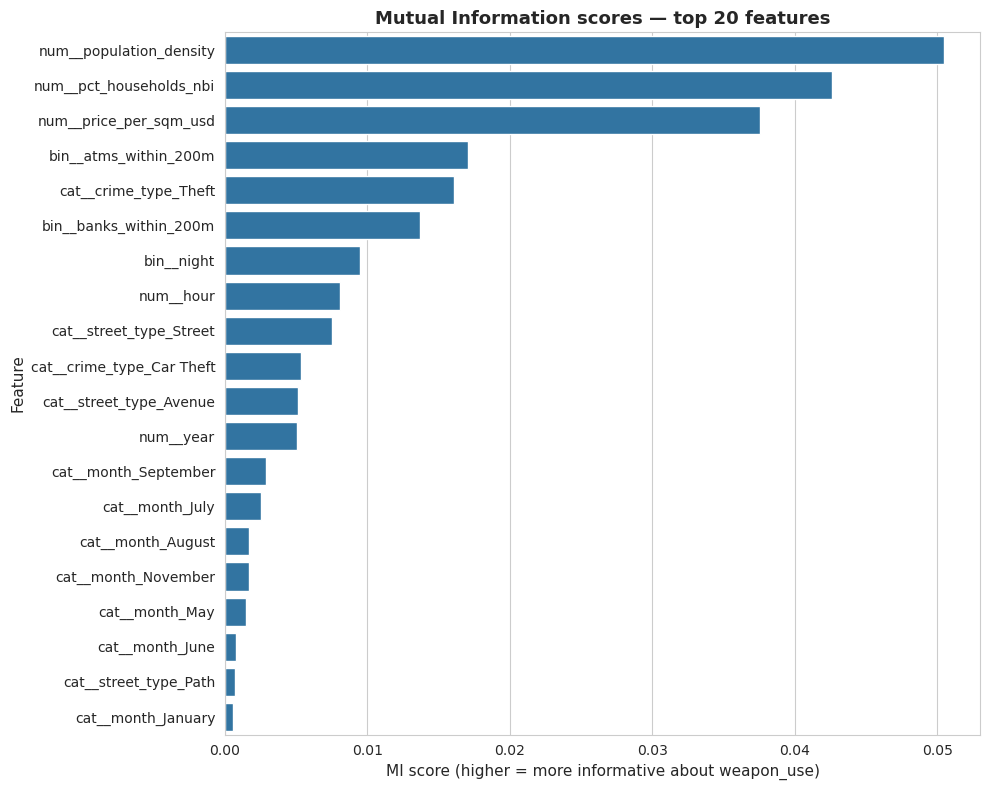

In [62]:
# Visualise top 20 features by MI score
plt.figure(figsize=(10, 8))
top_features_mi = mi_df.head(20)

sns.barplot(data=top_features_mi, x='mi_score', y='feature')
plt.title('Mutual Information scores — top 20 features')
plt.xlabel('MI score (higher = more informative about weapon_use)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [63]:
### Permutation Importance (PI)
#  PI measures the drop in model performance when each feature is randomly shuffled. It providing a model-specific view of feature 
# importance that complements the model-agnostic Mutual Information analysis. Together, MI and PI offer a robust basis for feature selection
# We use **recall** as the scoring metric, consistent with our model evaluation strategy.

# Permutation Importance computed on the test set using XGBoost v1
print("Computing Permutation Importance... this may take 1-3 minutes.")

perm_result = permutation_importance(
    best_xgb_v1,           # the trained pipeline (preprocessor + XGBoost)
    X_test,                # raw X_test (the pipeline handles preprocessing)
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Build DataFrame ordered by mean importance
pi_df = pd.DataFrame({
    'feature': X_test.columns,
    'pi_mean': perm_result.importances_mean,
    'pi_std':  perm_result.importances_std
}).sort_values('pi_mean', ascending=False).reset_index(drop=True)

print("\n=== Permutation Importance ===")
print(pi_df.to_string(index=False))

Computing Permutation Importance... this may take 1-3 minutes.

=== Permutation Importance ===
                    feature   pi_mean   pi_std
          price_per_sqm_usd  0.131000 0.006646
                       hour  0.025032 0.003633
         population_density  0.021742 0.004673
                       year  0.021129 0.003418
                street_type  0.015935 0.002141
           atms_within_200m  0.014774 0.002229
         pct_households_nbi  0.008516 0.002711
                      month  0.004452 0.003722
                 crime_type  0.004032 0.000844
          banks_within_200m  0.002290 0.001014
police_stations_within_200m  0.001677 0.000887
                      night -0.000129 0.001621


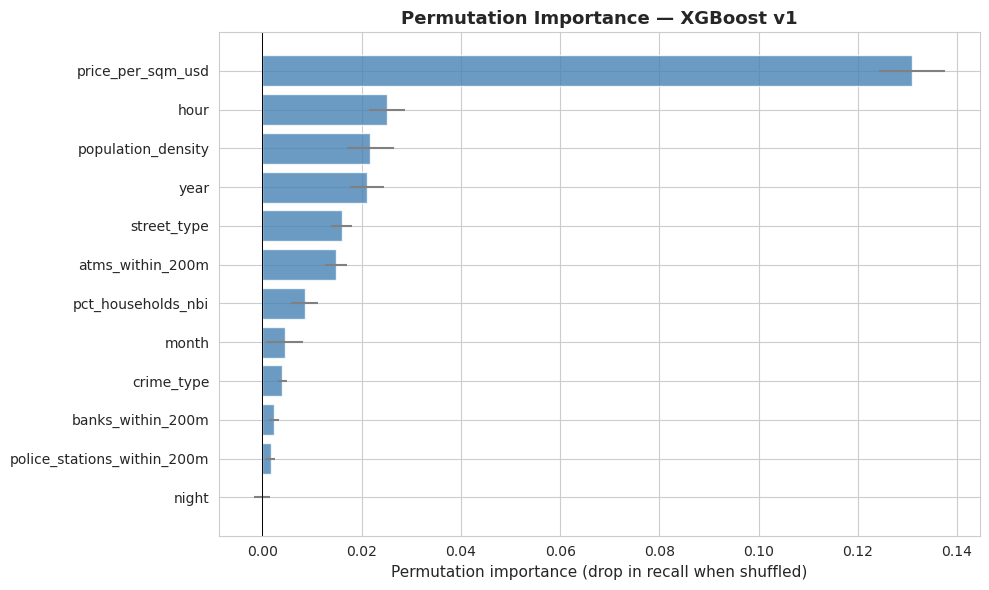

In [64]:
# Visualise PI as a horizontal bar chart with error bars
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(pi_df))

ax.barh(y_pos, pi_df['pi_mean'], xerr=pi_df['pi_std'],
        color='steelblue', alpha=0.8, error_kw={'ecolor': 'gray'})

ax.set_yticks(y_pos)
ax.set_yticklabels(pi_df['feature'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('Permutation importance (drop in recall when shuffled)')
ax.set_title('Permutation Importance — XGBoost v1')
plt.tight_layout()
plt.show()

### Feature irrelevance

Following MI + PI analysis, we remove the following features:

| Removed feature | MI score | PI score | Justification |
|---|---|---|---|
| `police_stations_within_200m` | 0.000 | 0.002 | Consensus: both MI and PI rank it as uninformative. |
| `month` | 0.008 (across 12 categories) | 0.004 | Consensus: minimal aggregated contribution despite many categories. |
| `night` | 0.009 | −0.0001 | PI is slightly negative: shuffling the variable does not degrade the model. The signal it carries is already captured by `hour` (PI: 0.025). |
| `banks_within_200m` | 0.014 | 0.002 | Redundant with `atms_within_200m` (PI: 0.015). |


In [65]:
# The retained feature set consists of **8 variables** that combine four complementary dimensions: 
# Temporal (`hour`, `year`)
# Socioeconomic (`price_per_sqm_usd`, `population_density`, `pct_households_nbi`)
# Spatial (`street_type`,`atms_within_200m`)
# Contextual (`crime_type`).

# Define the reduced feature set.
numeric_features_v2 = [
    'year', 'hour',
    'price_per_sqm_usd', 'population_density', 'pct_households_nbi'
]

categorical_features_v2 = [
    'street_type', 'crime_type'
]

binary_features_v2 = [
    'atms_within_200m'
]

features_v2 = numeric_features_v2 + categorical_features_v2 + binary_features_v2

# Filter columns from the existing train/test splits
X_train_v2 = X_train[features_v2].copy()
X_test_v2  = X_test[features_v2].copy()

# Summary
n_eliminated = X_train.shape[1] - X_train_v2.shape[1]
print(f"Reduced feature set: {len(features_v2)} features (down from {X_train.shape[1]})")
print(f"Eliminated: month, night, banks_within_200m, police_stations_within_200m")
print(f"\nX_train_v2 shape: {X_train_v2.shape[0]:,} × {X_train_v2.shape[1]}")
print(f"X_test_v2 shape:  {X_test_v2.shape[0]:,} × {X_test_v2.shape[1]}")


Reduced feature set: 8 features (down from 12)
Eliminated: month, night, banks_within_200m, police_stations_within_200m

X_train_v2 shape: 51,668 × 8
X_test_v2 shape:  12,917 × 8


In [66]:
# Build a new preprocessor reusing the same per-type pipelines but with the reduced feature lists
preprocessor_v2 = ColumnTransformer([
    ("num", numeric_pipe,     numeric_features_v2),
    ("bin", binary_pipe,      binary_features_v2),
    ("cat", categorical_pipe, categorical_features_v2)
])

print(f"Preprocessor v2 configured with {len(features_v2)} features "
      f"({len(numeric_features_v2)} numeric, {len(binary_features_v2)} binary, "
      f"{len(categorical_features_v2)} categorical).")

Preprocessor v2 configured with 8 features (5 numeric, 1 binary, 2 categorical).


In [67]:
# Reuse the optimal hyperparameters from XGBoost v1 (full feature set)
best_params_v1 = grid_xgb_v1.best_params_
print(f"Best hyperparameters from XGBoost v1: {best_params_v1}")

# Strip the 'classifier__' prefix to pass them directly to XGBClassifier
xgb_params = {k.replace('classifier__', ''): v for k, v in best_params_v1.items()}

# Build XGBoost v2: same preprocessor (reduced) + same hyperparameters as v1
xgb_pipe_v2 = Pipeline([
    ("preprocessor", preprocessor_v2),
    ("classifier",   XGBClassifier(
        **xgb_params,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

# Train on the reduced feature set
print("\nTraining XGBoost v2 (reduced feature set, hyperparameters from v1)...")
xgb_pipe_v2.fit(X_train_v2, y_train)
print("XGBoost v2 trained successfully.")

Best hyperparameters from XGBoost v1: {'classifier__max_depth': 3, 'classifier__min_split_loss': 1, 'classifier__subsample': 0.7}

Training XGBoost v2 (reduced feature set, hyperparameters from v1)...
XGBoost v2 trained successfully.


In [68]:
# Evaluate XGBoost v2 (reduced features, hyperparameters from v1) on train and test
best_xgb_v2 = xgb_pipe_v2   # already fit() in the previous cell

y_pred_train_xgb_v2  = best_xgb_v2.predict(X_train_v2)
y_pred_test_xgb_v2   = best_xgb_v2.predict(X_test_v2)
y_proba_train_xgb_v2 = best_xgb_v2.predict_proba(X_train_v2)[:, 1]
y_proba_test_xgb_v2  = best_xgb_v2.predict_proba(X_test_v2)[:, 1]

train_metrics_xgb_v2 = summarise_performance(y_train, y_pred_train_xgb_v2, y_proba_train_xgb_v2)
test_metrics_xgb_v2  = summarise_performance(y_test,  y_pred_test_xgb_v2,  y_proba_test_xgb_v2)

results_xgb_v2 = pd.DataFrame({
    'Train':        train_metrics_xgb_v2,
    'Test':         test_metrics_xgb_v2,
    'Train - Test': {k: train_metrics_xgb_v2[k] - test_metrics_xgb_v2[k] for k in train_metrics_xgb_v2}
}).round(3)

print("=== XGBoost v2 (reduced features) — Train vs Test performance ===\n")
print(results_xgb_v2)

print("\n--- Detailed test set classification report ---")
print(classification_report(y_test, y_pred_test_xgb_v2,
                            target_names=['No weapon', 'Weapon use'],
                            digits=3))

=== XGBoost v2 (reduced features) — Train vs Test performance ===

           Train   Test  Train - Test
precision  0.408  0.399         0.009
recall     0.662  0.640         0.023
f1         0.505  0.492         0.013
roc_auc    0.744  0.723         0.021

--- Detailed test set classification report ---
              precision    recall  f1-score   support

   No weapon      0.860     0.696     0.769      9817
  Weapon use      0.399     0.640     0.492      3100

    accuracy                          0.683     12917
   macro avg      0.629     0.668     0.630     12917
weighted avg      0.749     0.683     0.703     12917



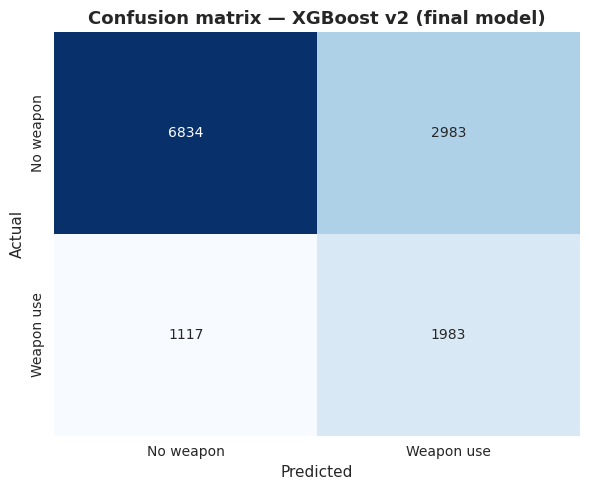


Total test examples: 12,917
True Positives (TP):  1,983  (correctly predicted weapon use)
True Negatives (TN):  6,834  (correctly predicted no weapon)
False Positives (FP): 2,983  (predicted weapon, none present)
False Negatives (FN): 1,117  (predicted no weapon, weapon present)


In [69]:
# Confusion matrix of the FINAL model (XGBoost v2)
cm_final = confusion_matrix(y_test, y_pred_test_xgb_v2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No weapon', 'Weapon use'],
            yticklabels=['No weapon', 'Weapon use'],
            cbar=False)
plt.title('Confusion matrix — XGBoost v2 (final model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Numerical summary
print(f"\nTotal test examples: {len(y_test):,}")
print(f"True Positives (TP):  {cm_final[1, 1]:,}  (correctly predicted weapon use)")
print(f"True Negatives (TN):  {cm_final[0, 0]:,}  (correctly predicted no weapon)")
print(f"False Positives (FP): {cm_final[0, 1]:,}  (predicted weapon, none present)")
print(f"False Negatives (FN): {cm_final[1, 0]:,}  (predicted no weapon, weapon present)")

**Results:**

The final model achieves recall = 0.640, F1 = 0.492 and ROC-AUC = 0.723 on the test set, correctly identifying approximately two-thirds of the actual weapon-involved crimes. The train-test gap is low (Δ ≤ 0.023), confirming successful regularisation. The trade-off between recall and precision is consistent with our public-safety-oriented evaluation strategy.


### Model interpretation


In [70]:
# To complement our findings, we apply SHAP (SHapley Additive exPlanations) to the final XGBoost model.
# SHAP provides instance-level interpretation: for each prediction, it quantifies how much each feature
# contributed (with direction and magnitude) to pushing the model toward "weapon use" or "no weapon".

# Extract the trained classifier and the preprocessor from the final model pipeline
xgb_classifier   = best_xgb_v2.named_steps['classifier']
xgb_preprocessor = best_xgb_v2.named_steps['preprocessor']

# Apply preprocessing to the test set
X_test_processed = xgb_preprocessor.transform(X_test_v2)

# Get feature names after preprocessing (after one-hot encoding)
feature_names_v2 = xgb_preprocessor.get_feature_names_out()

# Sample 1000 rows from test for faster SHAP computation
sample_size = 1000
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X_test_processed.shape[0], size=sample_size, replace=False)
X_sample = X_test_processed[sample_idx]

# Compute SHAP values using TreeExplainer (optimised for tree-based models)
print(f"Computing SHAP values for {sample_size} test samples...")
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_sample)
print("SHAP values computed. Shape:", shap_values.shape)

Computing SHAP values for 1000 test samples...
SHAP values computed. Shape: (1000, 13)


/tmp/ipykernel_42926/432765540.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


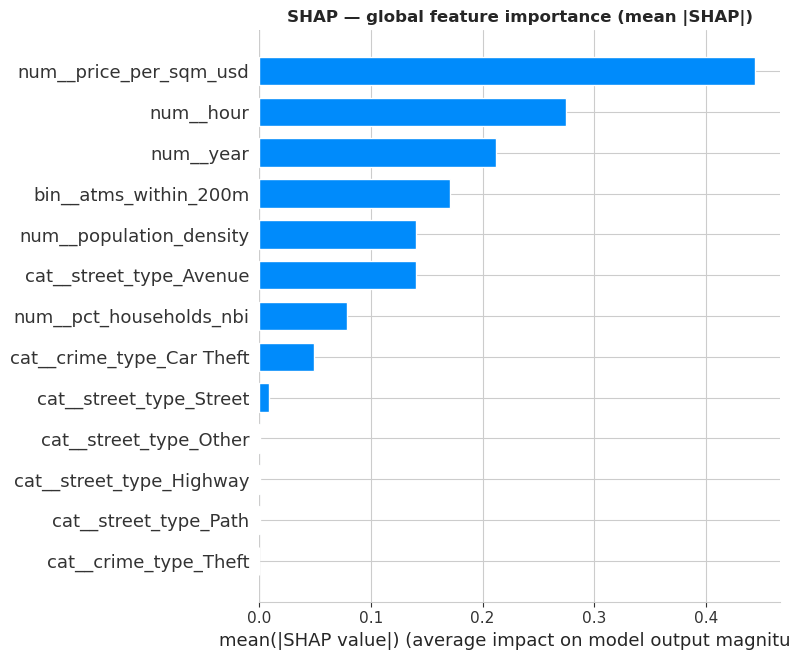

In [71]:
# Summary plot: bar chart of mean absolute SHAP values
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names_v2,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP — global feature importance (mean |SHAP|)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_42926/2909050213.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


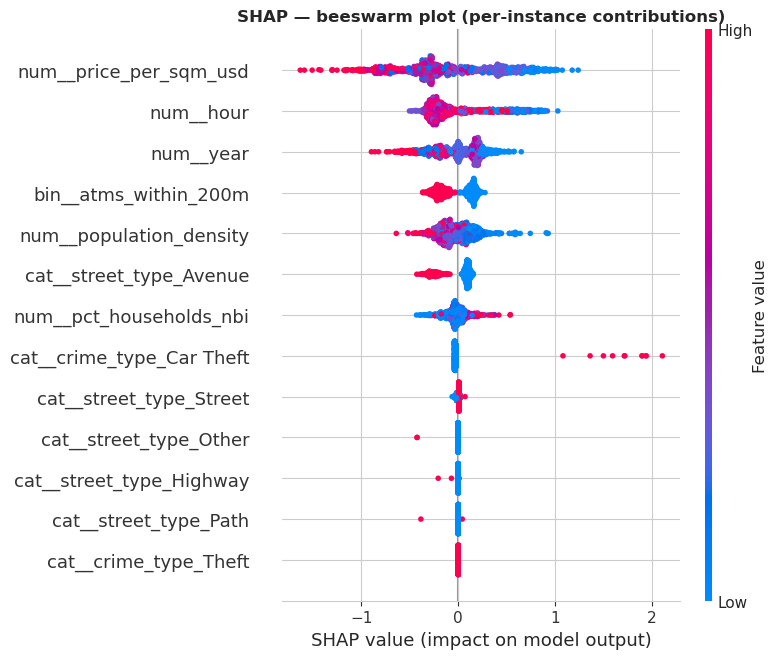

In [72]:
# Beeswarm plot: distribution of SHAP values per feature
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names_v2,
    show=False,
    max_display=15
)
plt.title('SHAP — beeswarm plot (per-instance contributions)', fontsize=12)
plt.tight_layout()
plt.show()

**Results:**

Overall, the SHAP analysis confirms PI. Three patterns stand out: 

+ Low `price_per_sqm_usd` pushes predictions toward "weapon use" and high prices push toward "no weapon".
+ `atms_within_200m` consistently produces negative SHAP, confirming the counterintuitive finding that proximity to financial infrastructure reduces weapon use.
+ `crime_type_Car Theft`, although globally rare, produces some of the **largest positive SHAP values**.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)


In [77]:
# Build a single comparison DataFrame for all three models on the TEST set
comparison = pd.DataFrame({
    'Logistic Regression': test_metrics,
    'Random Forest':       test_metrics_rf_v2,
    'XGBoost':             test_metrics_xgb_v2
}).round(3)

print("=== Model performance comparison (test set) ===\n")
print(comparison)

=== Model performance comparison (test set) ===

           Logistic Regression  Random Forest  XGBoost
precision                0.351          0.388    0.399
recall                   0.629          0.612    0.640
f1                       0.451          0.475    0.492
roc_auc                  0.675          0.710    0.723


## Conclusion

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined to what extent the use of a weapon in motorcycle-related crimes in Buenos Aires City can be predicted from temporal, spatial and socioeconomic features of the location and time of the event. Using a dataset of 64,585 records integrated from six public sources (2016–2024), three classification models were compared and a final XGBoost configuration was selected after Mutual Information and Permutation Importance feature selection. The model recovers ~64% of weapon-involved crimes in the test set with a ROC-AUC of 0.725, substantially above any trivial baseline. Three independent interpretability methods (MI, PI, SHAP) converged on the same set of dominant predictors — real estate price, hour, year, ATM proximity, population density and crime type — and confirmed a counterintuitive but theoretically coherent finding: **proximity to financial infrastructure is associated with lower weapon use**, in line with Routine Activity Theory. The remaining error is largely attributable to micro-level circumstances of each encounter that aggregate predictors cannot capture, suggesting that **richer, finer-grained features — rather than more complex models — represent the most promising path for future improvement**.

## Stakeholders of fire service research

It is important to consider the potential stakeholders who might benefit
from the insights derived from (geospatial) research of fire services.
As far as I know, potential stakeholders include:

1.  Local fire services including London Fire Brigade. Each fire service
    department has their data analyst and GIS team. They would be
    interested in understanding the patterns and trends of fire
    incidents to improve resource allocation, response times, and
    overall effectiveness of fire services. So far, the UK fire services
    don’t have lots of collaborations with academic researchers. If they
    need GIS expertise, they always outsource to private companies, such
    as [Cadcorp](https://www.cadcorp.com/) and
    [ORH](https://www.orhltd.com/).

2.  National Fire Chiefs Council (NFCC, [link](https://nfcc.org.uk/)).
    NFCC is a non-charity body representing Fire & Rescue Services at a
    national level and, as the professional voice of the fire and rescue
    service and aim for maximum impact. They strive to harness knowledge
    and expertise from across the country, bringing it together for the
    benefit of all.

## References

[[ go back to the top ]](#Table-of-contents)

*[Section to be completed.]*

In [ ]:
# Build a single comparison DataFrame for all three models on the TEST set
comparison = pd.DataFrame({
    'Logistic Regression':  test_metrics,
    'Random Forest (v2)':   test_metrics_rf2,
    'XGBoost (v2)':         test_metrics_xgb2
}).round(3)

print("=== Model performance comparison (test set) ===\n")
print(comparison)